In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
print("\nLoad and Prepare Data :")
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df = df.drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

X = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


Load and Prepare Data :
(5634, 30) (1409, 30)


In [3]:
print("\Logistic Regression :")
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

\Logistic Regression :


<>:1: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
<>:1: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
C:\Users\Adarsh\AppData\Local\Temp\ipykernel_1284\3949887237.py:1: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
  print("\Logistic Regression :")


Accuracy: 0.8048261178140526


c:\Users\Adarsh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
print("\nLogistic Regression Evaluation :")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))


Logistic Regression Evaluation :
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

ROC-AUC: 0.8427290810922524


In [5]:
print("\nDecision Tree :")

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, tree_pred))
print("ROC-AUC:", roc_auc_score(y_test, tree_model.predict_proba(X_test)[:, 1]))


Decision Tree :
Accuracy: 0.794180269694819
ROC-AUC: 0.8267043839933865


In [6]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [7]:
print("\n Rnadom Forest :")
# from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))


 Rnadom Forest :
Accuracy: 0.7877927608232789
ROC-AUC: 0.8245718050065877


In [8]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [9]:
print('\nRandom Forest Evaluation :')
print(classification_report(y_test, rf_pred))


Random Forest Evaluation :
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [10]:
print("\nModel Comparison :")
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, tree_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
    ]
})

results.round(3)


Model Comparison :


,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.805,0.843
1,Decision Tree,0.794,0.827
2,Random Forest,0.788,0.825



Confusion Matrix :


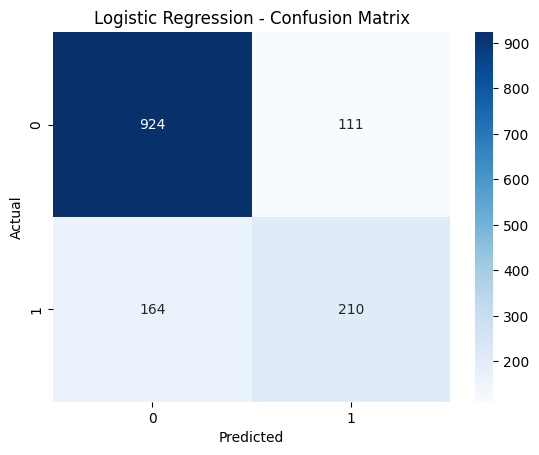

In [11]:
print("\nConfusion Matrix :")
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [12]:
print('\nConfusion Matrix :')
print(confusion_matrix(y_test, y_pred))


Confusion Matrix :
[[924 111]
 [164 210]]


In [13]:
print('\nFeature Importance - Logistic Regression :')
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance["Abs_Coefficient"] = importance["Coefficient"].abs()

importance.sort_values("Abs_Coefficient", ascending=False).head(10)


Feature Importance - Logistic Regression :


,Feature,Coefficient,Abs_Coefficient
25,Contract_Two year,-1.325214,1.325214
10,InternetService_Fiber optic,0.742896,0.742896
24,Contract_One year,-0.684531,0.684531
13,OnlineSecurity_Yes,-0.437039,0.437039
7,PhoneService_Yes,-0.430754,0.430754
19,TechSupport_Yes,-0.389446,0.389446
28,PaymentMethod_Electronic check,0.387787,0.387787
26,PaperlessBilling_Yes,0.376456,0.376456
9,MultipleLines_Yes,0.274968,0.274968
6,Dependents_Yes,-0.219680,0.219680



Feature Importance Plot :


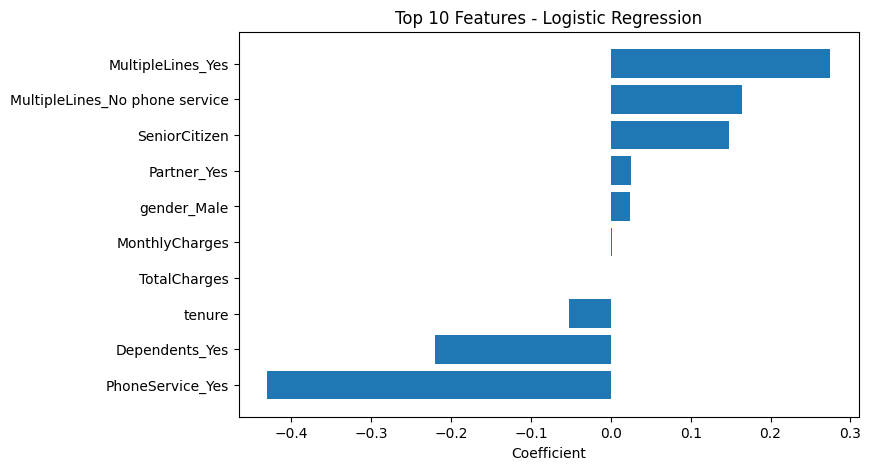

In [14]:
print('\nFeature Importance Plot :')
top_features = importance.head(10).sort_values("Coefficient")

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Top 10 Features - Logistic Regression")
plt.show()

In [15]:
print('\nCreate Model Folder :')
import os

os.makedirs("model", exist_ok=True)


Create Model Folder :


In [16]:
print('\nSave Model :')
import joblib

joblib.dump(model, "model/logistic_regression_model.pkl")




Save Model :


['model/logistic_regression_model.pkl']

In [17]:
print('\nSave Feature Names :')
joblib.dump(X.columns.tolist(), "model/feature_names.pkl")


Save Feature Names :


['model/feature_names.pkl']